# Brain Tumor Classification - Model Comparison

Comparing 4 models:
1. Custom CNN (128x128)
2. VGG16 (224x224)
3. InceptionV3 (224x224)
4. DenseNet121 (224x224)


## Setup & Dataset Loading


In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# Install and setup Kaggle
%pip install -q kaggle
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
# Download dataset
!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset
!unzip -q brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset


Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): CC0-1.0
 99% 147M/149M [00:00<00:00, 1.54GB/s]
100% 149M/149M [00:00<00:00, 1.53GB/s]


In [4]:
# Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

TEST_DIR = "/content/brain_tumor_dataset/Testing"
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']


## Load Models from Drive


In [5]:
# Model paths in Google Drive
DRIVE_PATH = "/content/drive/MyDrive/SE4050-Deep Learning"

print("Loading models...")
model_custom = load_model(f"{DRIVE_PATH}/brain_tumor_cnn_model_1.keras")
model_vgg16 = load_model(f"{DRIVE_PATH}/vgg16_phase2.keras")
model_inception = load_model(f"{DRIVE_PATH}/inceptionv3_final.keras")
model_densenet = load_model(f"{DRIVE_PATH}/densenet_phase2.keras")
print("✓ All models loaded successfully")


Loading models...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 32 variables whereas the saved optimizer has 66 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✓ All models loaded successfully


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 50 variables whereas the saved optimizer has 54 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Prepare Test Datasets


In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Custom CNN (128x128)
test_gen_128 = ImageDataGenerator(rescale=1./255).flow_from_directory(
    TEST_DIR, target_size=(128, 128), batch_size=32,
    class_mode='categorical', shuffle=False
)

# VGG16 (224x224 with VGG preprocessing)
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
test_gen_vgg = ImageDataGenerator(preprocessing_function=vgg_preprocess).flow_from_directory(
    TEST_DIR, target_size=(224, 224), batch_size=32,
    class_mode='categorical', shuffle=False
)

# InceptionV3 (224x224 with Inception preprocessing)
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess
test_gen_inception = ImageDataGenerator(preprocessing_function=inception_preprocess).flow_from_directory(
    TEST_DIR, target_size=(224, 224), batch_size=32,
    class_mode='categorical', shuffle=False
)

# DenseNet (224x224 with DenseNet preprocessing)
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess
test_gen_densenet = ImageDataGenerator(preprocessing_function=densenet_preprocess).flow_from_directory(
    TEST_DIR, target_size=(224, 224), batch_size=32,
    class_mode='categorical', shuffle=False
)


Found 1311 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.


## Evaluate All Models


In [9]:
print("Evaluating models...\n")

# Custom CNN
results_custom = model_custom.evaluate(test_gen_128, verbose=0)
loss_custom, acc_custom = results_custom[:2]
y_pred_custom = np.argmax(model_custom.predict(test_gen_128, verbose=0), axis=1)
y_true = test_gen_128.classes

# VGG16
results_vgg = model_vgg16.evaluate(test_gen_vgg, verbose=0)
loss_vgg, acc_vgg = results_vgg[:2]
y_pred_vgg = np.argmax(model_vgg16.predict(test_gen_vgg, verbose=0), axis=1)

# InceptionV3
results_inception = model_inception.evaluate(test_gen_inception, verbose=0)
loss_inception, acc_inception = results_inception[:2]
y_pred_inception = np.argmax(model_inception.predict(test_gen_inception, verbose=0), axis=1)

# DenseNet
results_densenet = model_densenet.evaluate(test_gen_densenet, verbose=0)
loss_densenet, acc_densenet = results_densenet[:2]
y_pred_densenet = np.argmax(model_densenet.predict(test_gen_densenet, verbose=0), axis=1)

print("✓ Evaluation complete")

Evaluating models...



/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


✓ Evaluation complete


## Performance Comparison


In [10]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16', 'InceptionV3', 'DenseNet121'],
    'Input Size': ['128x128', '224x224', '224x224', '224x224'],
    'Test Accuracy (%)': [
        acc_custom * 100,
        acc_vgg * 100,
        acc_inception * 100,
        acc_densenet * 100
    ],
    'Test Loss': [loss_custom, loss_vgg, loss_inception, loss_densenet]
})

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(results.to_string(index=False))
print("="*60)

# Find best model
best_idx = results['Test Accuracy (%)'].idxmax()
print(f"\n🏆 Best Model: {results.loc[best_idx, 'Model']} with {results.loc[best_idx, 'Test Accuracy (%)']:.2f}% accuracy")



MODEL COMPARISON SUMMARY
      Model Input Size  Test Accuracy (%)  Test Loss
 Custom CNN    128x128          91.304350   0.257560
      VGG16    224x224          95.957285   0.143393
InceptionV3    224x224          85.964912   0.386579
DenseNet121    224x224          82.761252   0.416086

🏆 Best Model: VGG16 with 95.96% accuracy


## Visualization


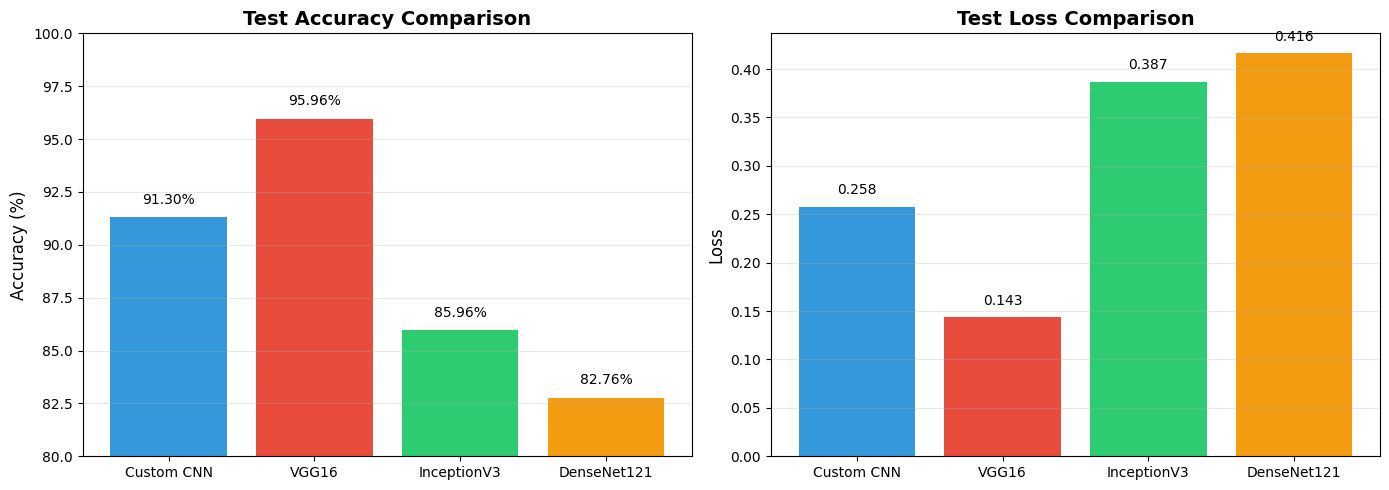

In [11]:
# Bar plot comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
ax1.bar(results['Model'], results['Test Accuracy (%)'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylim([80, 100])
ax1.grid(axis='y', alpha=0.3)
for i, v in enumerate(results['Test Accuracy (%)']):
    ax1.text(i, v + 0.5, f'{v:.2f}%', ha='center', va='bottom', fontsize=10)

# Loss comparison
ax2.bar(results['Model'], results['Test Loss'], color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'])
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Test Loss Comparison', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)
for i, v in enumerate(results['Test Loss']):
    ax2.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()


## Per-Class Performance


In [12]:
models_preds = [
    ('Custom CNN', y_pred_custom),
    ('VGG16', y_pred_vgg),
    ('InceptionV3', y_pred_inception),
    ('DenseNet121', y_pred_densenet)
]

print("\nPER-CLASS PERFORMANCE\n" + "="*80)
for model_name, y_pred in models_preds:
    print(f"\n{model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))



PER-CLASS PERFORMANCE

Custom CNN:
              precision    recall  f1-score   support

      glioma      0.996     0.830     0.905       300
  meningioma      0.831     0.817     0.824       306
     notumor      0.905     0.988     0.945       405
   pituitary      0.937     0.993     0.964       300

    accuracy                          0.913      1311
   macro avg      0.917     0.907     0.910      1311
weighted avg      0.916     0.913     0.912      1311


VGG16:
              precision    recall  f1-score   support

      glioma      0.986     0.960     0.973       300
  meningioma      0.971     0.879     0.923       306
     notumor      0.983     0.993     0.988       405
   pituitary      0.898     0.997     0.945       300

    accuracy                          0.960      1311
   macro avg      0.960     0.957     0.957      1311
weighted avg      0.961     0.960     0.959      1311


InceptionV3:
              precision    recall  f1-score   support

      glioma     

## Confusion Matrices


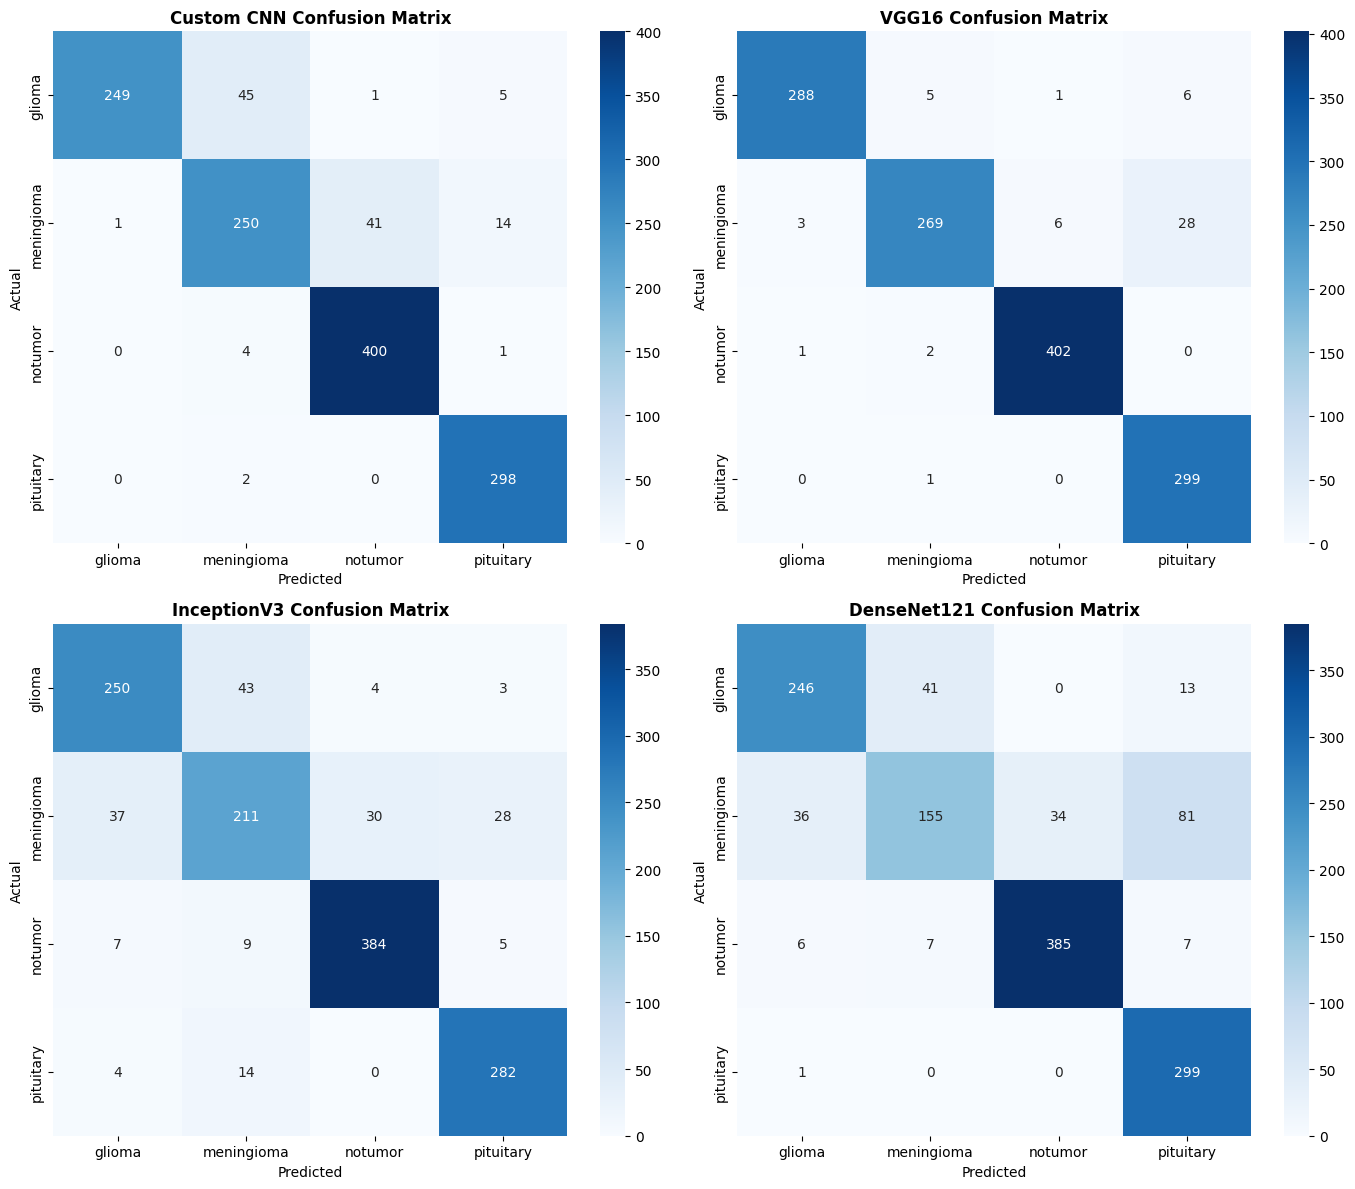

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (model_name, y_pred) in enumerate(models_preds):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[idx], cbar=True)
    axes[idx].set_title(f'{model_name} Confusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10)
    axes[idx].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()


## Model Architecture Comparison


In [14]:
# Parameter counts
arch_comparison = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16', 'InceptionV3', 'DenseNet121'],
    'Total Parameters': [
        model_custom.count_params(),
        model_vgg16.count_params(),
        model_inception.count_params(),
        model_densenet.count_params()
    ],
    'Architecture': ['Custom', 'Transfer Learning', 'Transfer Learning', 'Transfer Learning']
})

print("\nMODEL ARCHITECTURE COMPARISON")
print("="*60)
print(arch_comparison.to_string(index=False))
print("="*60)



MODEL ARCHITECTURE COMPARISON
      Model  Total Parameters      Architecture
 Custom CNN           3321476            Custom
      VGG16          14847044 Transfer Learning
InceptionV3          22328356 Transfer Learning
DenseNet121           7300932 Transfer Learning


## Key Findings

### Summary:
- **Best Performer**: VGG16 achieved highest accuracy (95.96%) and lowest loss (0.143).
- **Most Efficient**: Custom CNN uses smallest input (128x128) with good accuracy (91.30%) and the fewest parameters (3.3M).
- **Transfer Learning**: VGG16, InceptionV3, and DenseNet leverage pre-trained ImageNet weights. DenseNet121 has a good balance of parameters (7.3M) and accuracy (82.76%).

### Observations:
1. **VGG16** performs best due to its deep architecture and effective feature extraction, showing high precision and recall across most classes, especially 'notumor' and 'pituitary'.
2. **Custom CNN** achieves competitive results despite simpler architecture and smaller input, with strong performance on 'glioma' and 'notumor'.
3. **DenseNet121** shows good performance with parameter efficiency, but struggles with 'meningioma' recall.
4. **InceptionV3** performance is generally lower than VGG16 and Custom CNN, particularly for 'meningioma'.